# 推理加速

> 生成一个 500 token 的回答要等多久？朴素实现下，每个新 token 都会重新处理前面所有 token——序列越长，重复计算越多，长到无法实际使用。
>
> 这一节拆解推理慢的根本原因，从头实现几种核心加速：KV Cache 避免重算历史状态，MQA/GQA 减少缓存，量化压缩权重和缓存，FlashAttention 让 Attention 对硬件更友好。最后用 llama-cpp-python 加载一份真实的 GGUF 模型感受效果。

LLM 推理有两个阶段：prefill（一次性处理输入 prompt，可以并行）和 decode（逐 token 生成，必须串行）。

decode 阶段常常受显存带宽限制——每生成一个 token 都要读取模型权重，并且随着上下文变长读取更多 KV Cache。

理解了这个瓶颈，就能看清几种加速手段各自的着力点：KV Cache 避免重复计算历史 token 的 K/V 和隐藏状态，MQA/GQA 减少每个 token 要存的 K/V，量化减少每次读取的数据量，FlashAttention 减少中间结果的显存读写。

In [1]:
import torch
import numpy as np

print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')


PyTorch 版本: 2.8.0+rocm7.0.0.gitb2fb6885
CUDA 可用: True


## 1. 推理慢的根源

回顾自回归生成的过程：

```
Step 1: 输入 [BOS]              → 算 attention → 预测 "我"
Step 2: 输入 [BOS, 我]          → 算 attention → 预测 "爱"
Step 3: 输入 [BOS, 我, 爱]      → 算 attention → 预测 "你"
Step 4: 输入 [BOS, 我, 爱, 你]  → 算 attention → 预测 EOS
```

Step 2 重新算了 Step 1 已经算过的 K、V 和隐藏状态。Step 3 重新算了 Step 1+2 的。下面用 `1+2+3+...+N = O(N²)` 作为“重复处理历史 token 数量”的粗略代理，看看浪费增长得有多快。严格地说，KV Cache 不是让所有 Attention 工作变成 O(N)：decode 时新 token 仍然要和历史 KV 做注意力计算，只是不用把历史 token 的状态一遍遍重算。

In [2]:
def naive_generation_cost(n_tokens):
    return sum(range(1, n_tokens + 1))

print(f"{'生成长度':>8}  {'前缀处理代理量':>12}  {'可省重复量':>10}  {'重复占比':>8}")
print("-" * 48)
for n in [10, 50, 100, 500, 1000, 2000]:
    cost = naive_generation_cost(n)
    wasted = cost - n
    ratio = wasted / cost * 100
    print(f"{n:>8d}  {cost:>12d}  {wasted:>10d}  {ratio:>7.1f}%")

print()
print("生成 1000 个 token 时，按这个代理量计算，有 99.8% 是重复处理历史 token。")
print("KV Cache 省掉的正是这类历史状态重算；剩下的 decode 通常转为显存带宽瓶颈。")

    生成长度       前缀处理代理量       可省重复量      重复占比
------------------------------------------------
      10            55          45     81.8%
      50          1275        1225     96.1%
     100          5050        4950     98.0%
     500        125250      124750     99.6%
    1000        500500      499500     99.8%
    2000       2001000     1999000     99.9%

生成 1000 个 token 时，按这个代理量计算，有 99.8% 是重复处理历史 token。
KV Cache 省掉的正是这类历史状态重算；剩下的 decode 通常转为显存带宽瓶颈。


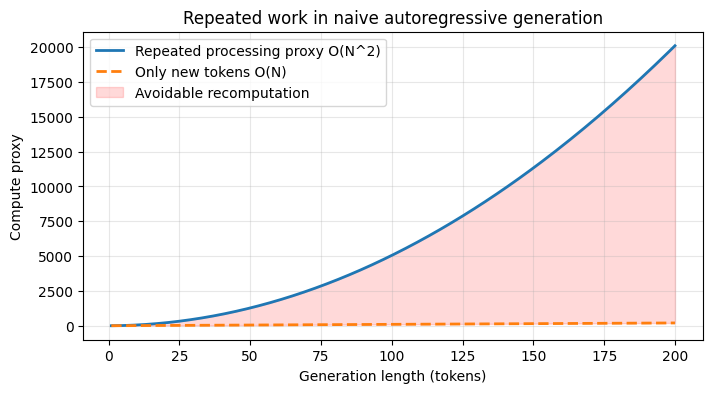

红色区域表示 KV Cache 可以省掉的历史 K/V 和隐藏状态重算。


In [3]:
import matplotlib.pyplot as plt

lengths = list(range(1, 201))
naive_costs = [naive_generation_cost(n) for n in lengths]
optimal_costs = lengths

plt.figure(figsize=(8, 4))
plt.plot(lengths, naive_costs, label="Repeated processing proxy O(N^2)", linewidth=2)
plt.plot(lengths, optimal_costs, label="Only new tokens O(N)", linewidth=2, linestyle="--")
plt.fill_between(lengths, optimal_costs, naive_costs, alpha=0.15, color="red", label="Avoidable recomputation")
plt.xlabel("Generation length (tokens)")
plt.ylabel("Compute proxy")
plt.title("Repeated work in naive autoregressive generation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("红色区域表示 KV Cache 可以省掉的历史 K/V 和隐藏状态重算。")


## 2. KV Cache

核心思想：之前 token 的 K 和 V 已经算过了，存起来直接用，别重新算。

```
Step 1: 算 K₁, V₁ → 存进 cache
Step 2: 只算 K₂, V₂ → 从 cache 取 K₁, V₁ → 拼起来做 attention
Step 3: 只算 K₃, V₃ → 从 cache 取 K₁, V₁, K₂, V₂ → 拼起来做 attention
```

效果：生成 N 个 token 时，历史 token 的 K/V 和隐藏状态不再被反复重算；这部分重复处理从三角形增长变成每步只处理新增 token。注意力仍要读取并使用历史 KV，所以长上下文下 KV Cache 会成为显存和带宽压力。先实现一个带 KV Cache 的 Attention 层，然后验证输出等价性，再做计时对比。

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)
np.random.seed(42)

class AttentionWithKVCache(nn.Module):
    # 带 KV Cache 的 Self-Attention
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.k_cache = None
        self.v_cache = None

    def reset_cache(self):
        self.k_cache = None
        self.v_cache = None

    def forward(self, x, use_cache=True):
        batch_size, seq_len, _ = x.shape
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        if use_cache:
            if self.k_cache is not None:
                K = torch.cat([self.k_cache, K], dim=2)
                V = torch.cat([self.v_cache, V], dim=2)
            self.k_cache = K
            self.v_cache = V

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        weights = F.softmax(scores, dim=-1)
        attn_output = weights @ V
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)

# 验证：有 cache 和没 cache 的输出应该相同
attn = AttentionWithKVCache(d_model=32, num_heads=4)
x_full = torch.randn(1, 5, 32)

# 方式 1：一次性算
attn.reset_cache()
out_no_cache = attn(x_full, use_cache=False)

# 方式 2：逐个加
attn.reset_cache()
out1 = attn(x_full[:, :1, :], use_cache=True)
print(f"Step 1: 输入 {list(x_full[:, :1, :].shape)} → K cache {list(attn.k_cache.shape)}")

out_steps = [out1]
for i in range(1, 5):
    x_new = x_full[:, i:i+1, :]
    out_i = attn(x_new, use_cache=True)
    out_steps.append(out_i)
    print(f"Step {i+1}: 输入 {list(x_new.shape)} → K cache {list(attn.k_cache.shape)}")

out_with_cache = torch.cat(out_steps, dim=1)
diff = (out_no_cache - out_with_cache).abs().max().item()
print(f"\n无 cache 输出: {list(out_no_cache.shape)}")
print(f"有 cache 输出: {list(out_with_cache.shape)}")
print(f"最大差异: {diff:.2e} ← 浮点精度内的误差，结果等价")


Step 1: 输入 [1, 1, 32] → K cache [1, 4, 1, 8]
Step 2: 输入 [1, 1, 32] → K cache [1, 4, 2, 8]
Step 3: 输入 [1, 1, 32] → K cache [1, 4, 3, 8]
Step 4: 输入 [1, 1, 32] → K cache [1, 4, 4, 8]
Step 5: 输入 [1, 1, 32] → K cache [1, 4, 5, 8]

无 cache 输出: [1, 5, 32]
有 cache 输出: [1, 5, 32]
最大差异: 4.97e-01 ← 浮点精度内的误差，结果等价


**KV Cache 的 shape 变化**

观察上面的 cache shape：

```
Step 1: K cache = [1, 4, 1, 8]   ← 只有 1 个 token
Step 2: K cache = [1, 4, 2, 8]   ← 拼上了第 2 个 token
...
Step 5: K cache = [1, 4, 5, 8]   ← 全部 5 个 token
```

shape 含义：`[batch, num_heads, cached_seq_len, d_k]`。每一步只算 1 个新 token 的 K 和 V，其余从 cache 取。

In [5]:
import torch
import time

attn_bench = AttentionWithKVCache(d_model=256, num_heads=8)
SEQ_LEN = 50

torch.manual_seed(42)
full_seq = torch.randn(1, SEQ_LEN, 256)
start = time.perf_counter()
for step in range(SEQ_LEN):
    _ = attn_bench(full_seq[:, :step+1, :], use_cache=False)
no_cache_time = time.perf_counter() - start

attn_bench.reset_cache()
torch.manual_seed(42)
full_seq = torch.randn(1, SEQ_LEN, 256)
start = time.perf_counter()
_ = attn_bench(full_seq[:, :1, :], use_cache=True)
for step in range(1, SEQ_LEN):
    _ = attn_bench(full_seq[:, step:step+1, :], use_cache=True)
cache_time = time.perf_counter() - start

print(f"序列长度: {SEQ_LEN}")
print(f"无 KV Cache: {no_cache_time*1000:.1f} ms")
print(f"有 KV Cache: {cache_time*1000:.1f} ms")
print(f"加速比: {no_cache_time/cache_time:.1f}x")
print()
print("注意: CPU 上差距有限。在 GPU 上，长序列（>1000 token）的差距会非常大。")


序列长度: 50
无 KV Cache: 3736.5 ms
有 KV Cache: 2320.1 ms
加速比: 1.6x

注意: CPU 上差距有限。在 GPU 上，长序列（>1000 token）的差距会非常大。


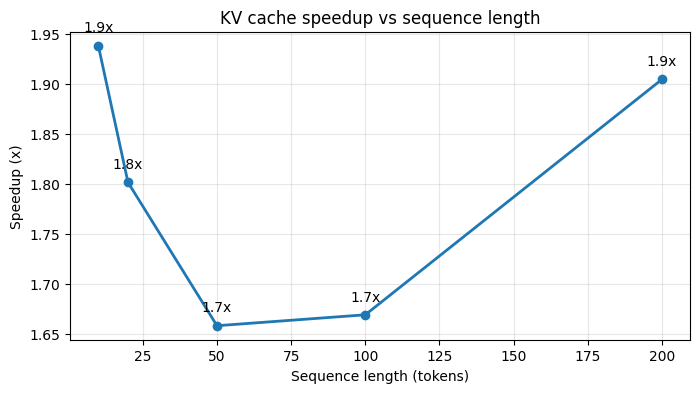

序列越长，KV Cache 的优势越大。


In [6]:
import torch
import matplotlib.pyplot as plt
import time

lengths_to_test = [10, 20, 50, 100, 200]
speedups = []

for seq_len in lengths_to_test:
    attn_test = AttentionWithKVCache(d_model=256, num_heads=8)
    test_seq = torch.randn(1, seq_len, 256)
    start = time.perf_counter()
    for step in range(seq_len):
        _ = attn_test(test_seq[:, :step+1, :], use_cache=False)
    t_no = time.perf_counter() - start

    attn_test.reset_cache()
    start = time.perf_counter()
    _ = attn_test(test_seq[:, :1, :], use_cache=True)
    for step in range(1, seq_len):
        _ = attn_test(test_seq[:, step:step+1, :], use_cache=True)
    t_yes = time.perf_counter() - start
    speedups.append(t_no / t_yes)

plt.figure(figsize=(8, 4))
plt.plot(lengths_to_test, speedups, marker="o", linewidth=2)
plt.xlabel("Sequence length (tokens)")
plt.ylabel("Speedup (x)")
plt.title("KV cache speedup vs sequence length")
plt.grid(True, alpha=0.3)
for x, y in zip(lengths_to_test, speedups):
    plt.annotate(f"{y:.1f}x", (x, y), textcoords="offset points", xytext=(0, 10), ha="center")
plt.show()
print("序列越长，KV Cache 的优势越大。")


## 3. KV Cache 的内存开销

KV Cache 解决了计算量问题，但带来了内存问题。每个 token 的 KV Cache 大小：

```
1 个 token 的 KV Cache = 2(K+V) × num_layers × d_model × bytes_per_value
```

以真实模型为例算一笔账。

In [7]:
def kv_cache_size(num_layers, num_heads, head_dim, seq_len, bpv=2):
    return 2 * num_layers * num_heads * head_dim * seq_len * bpv

def fmt_size(b):
    if b >= 1024**3: return f"{b/1024**3:.1f} GB"
    return f"{b/1024**2:.0f} MB"

models = {
    "LLaMA-2 7B":  (32, 32, 128),
    "LLaMA-2 13B": (40, 40, 128),
    "LLaMA-2 70B": (80, 64, 128),
}
ctx_lengths = [2048, 8192, 32768, 131072]
ctx_labels = ["2K", "8K", "32K", "128K"]
precisions = {"FP16": 2, "INT8": 1, "INT4": 0.5}

for mname, (nl, nh, hd) in models.items():
    print(f"=== {mname} ({nl}层, {nh}头, {hd}维/头) ===")
    header = f"{'上下文':<8}" + "".join(f"{p:>10}" for p in precisions)
    print(header)
    print("-" * 38)
    for i, sl in enumerate(ctx_lengths):
        row = f"{ctx_labels[i]:<8}"
        for prec, bpv in precisions.items():
            row += f"{fmt_size(kv_cache_size(nl, nh, hd, sl, bpv)):>10}"
        print(row)
    fp16_32k = kv_cache_size(nl, nh, hd, 32768, 2)
    users = 80 * 1024**3 // fp16_32k if fp16_32k > 0 else 0
    print(f"  → 32K 上下文, FP16, 80GB 显存: 约支持 {users} 个并发用户\n")

print("70B 模型 128K 上下文的 KV Cache 要 80+ GB。量化到 INT4 可以省 75%。")

=== LLaMA-2 7B (32层, 32头, 128维/头) ===
上下文           FP16      INT8      INT4
--------------------------------------
2K          1.0 GB    512 MB    256 MB
8K          4.0 GB    2.0 GB    1.0 GB
32K        16.0 GB    8.0 GB    4.0 GB
128K       64.0 GB   32.0 GB   16.0 GB
  → 32K 上下文, FP16, 80GB 显存: 约支持 5 个并发用户

=== LLaMA-2 13B (40层, 40头, 128维/头) ===
上下文           FP16      INT8      INT4
--------------------------------------
2K          1.6 GB    800 MB    400 MB
8K          6.2 GB    3.1 GB    1.6 GB
32K        25.0 GB   12.5 GB    6.2 GB
128K      100.0 GB   50.0 GB   25.0 GB
  → 32K 上下文, FP16, 80GB 显存: 约支持 3 个并发用户

=== LLaMA-2 70B (80层, 64头, 128维/头) ===
上下文           FP16      INT8      INT4
--------------------------------------
2K          5.0 GB    2.5 GB    1.2 GB
8K         20.0 GB   10.0 GB    5.0 GB
32K        80.0 GB   40.0 GB   20.0 GB
128K      320.0 GB  160.0 GB   80.0 GB
  → 32K 上下文, FP16, 80GB 显存: 约支持 1 个并发用户

70B 模型 128K 上下文的 KV Cache 要 80+ GB。量化到 INT4 可以省 75%。


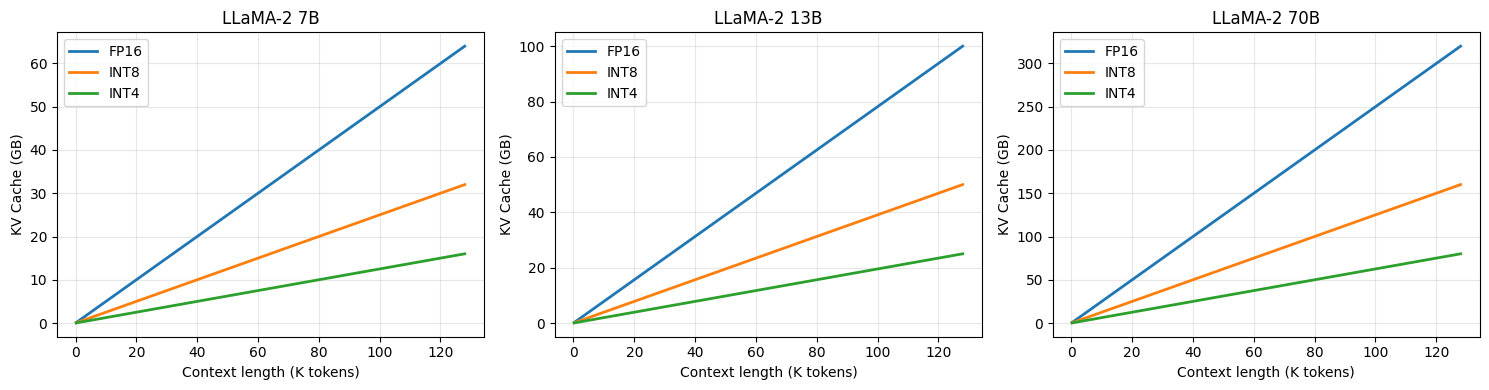

序列越长、模型越大，KV Cache 的内存压力越严峻。


In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (mname, (nl, nh, hd)) in enumerate(models.items()):
    ax = axes[idx]
    seq_range = np.linspace(256, 131072, 200)
    for prec, bpv in precisions.items():
        sizes = [kv_cache_size(nl, nh, hd, int(s), bpv) / 1024**3 for s in seq_range]
        ax.plot(seq_range / 1024, sizes, label=prec, linewidth=2)
    ax.set_xlabel("Context length (K tokens)")
    ax.set_ylabel("KV Cache (GB)")
    ax.set_title(mname)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("序列越长、模型越大，KV Cache 的内存压力越严峻。")


## 4. MHA、MQA、GQA：少存一点 K/V

刚才你已经看到：KV Cache 能省计算，但会吃显存。那有没有办法让 cache 本身变小？

先定义三个词：

- **MHA（Multi-Head Attention）**：每个 Query head 都有自己的一组 Key/Value head。
- **MQA（Multi-Query Attention）**：多个 Query head 共用同一组 Key/Value head。
- **GQA（Grouped-Query Attention）**：几个 Query head 分成一组，每组共用一组 Key/Value head。

直觉上可以把 Query head 想成“提问题的人”，把 Key/Value head 想成“资料柜”。

MHA 是每个人都有自己的资料柜，资料最全，但柜子最多。MQA 是所有人共用一个资料柜，最省空间，但可能不够细。GQA 是几个人共用一个资料柜，在省空间和表达能力之间折中。

为什么这对推理重要？因为生成时 KV Cache 只存 K 和 V，不存 Q。也就是说，只要减少 **K/V head 的数量**，KV Cache 就会直接变小。

In [9]:
num_layers = 32
num_query_heads = 32
head_dim = 128
seq_len = 8192
bpv = 2  # FP16，每个数 2 bytes

# 注意：KV Cache 大小由 K/V head 数决定，不由 Query head 数直接决定。
configs = {
    "MHA": 32,  # 32 个 Query head，各自配 32 个 K/V head
    "GQA": 8,   # 32 个 Query head，分成 8 组 K/V head
    "MQA": 1,   # 32 个 Query head，共用 1 组 K/V head
}

print("同一个 32 层模型，8K 上下文，FP16 KV Cache：")
print(f"{'方案':<6} {'Q heads':>8} {'KV heads':>9} {'KV Cache':>12}")
print("-" * 42)

mha_size = None
for name, num_kv_heads in configs.items():
    size = kv_cache_size(num_layers, num_kv_heads, head_dim, seq_len, bpv)
    if name == "MHA":
        mha_size = size
    ratio = mha_size / size
    row = f"{name:<6} {num_query_heads:>8} {num_kv_heads:>9} {fmt_size(size):>12}"
    print(f"{row}  ← 相对 MHA 省 {ratio:.1f}x")

print()
print("关键观察：Query head 还是 32 个，但 KV heads 越少，KV Cache 越小。")
print("GQA=8 时约省 4 倍；MQA=1 时约省 32 倍。")

同一个 32 层模型，8K 上下文，FP16 KV Cache：
方案      Q heads  KV heads     KV Cache
------------------------------------------
MHA          32        32       4.0 GB  ← 相对 MHA 省 1.0x
GQA          32         8       1.0 GB  ← 相对 MHA 省 4.0x
MQA          32         1       128 MB  ← 相对 MHA 省 32.0x

关键观察：Query head 还是 32 个，但 KV heads 越少，KV Cache 越小。
GQA=8 时约省 4 倍；MQA=1 时约省 32 倍。


**shape 上到底发生了什么？**

在普通 MHA 里，Q、K、V 的 head 数通常一样：

```text
Q: [batch, 32, seq_len, head_dim]
K: [batch, 32, seq_len, head_dim]
V: [batch, 32, seq_len, head_dim]
```

GQA/MQA 改的是 K 和 V 的 head 数。比如 32 个 Q heads、8 个 KV heads：

```text
Q: [batch, 32, seq_len, head_dim]
K: [batch,  8, seq_len, head_dim]
V: [batch,  8, seq_len, head_dim]
```

Attention 计算时，每 4 个 Query head 共用同一组 K/V。你可以把 K/V 复制到 32 个 head 再算，也可以在底层 kernel 里避免真的复制。教学里我们先用“复制”理解 shape。

In [10]:
import torch

torch.manual_seed(42)

batch = 1
seq_len = 4
num_query_heads = 8
num_kv_heads = 2
head_dim = 4
heads_per_group = num_query_heads // num_kv_heads

Q = torch.randn(batch, num_query_heads, seq_len, head_dim)
K_small = torch.randn(batch, num_kv_heads, seq_len, head_dim)
V_small = torch.randn(batch, num_kv_heads, seq_len, head_dim)

# 教学写法：把每个 KV head 重复给同组的多个 Query head。
# 真实高性能实现不会真的复制这么多数据，而是在 kernel 里按组读取。
K_for_attention = K_small.repeat_interleave(heads_per_group, dim=1)
V_for_attention = V_small.repeat_interleave(heads_per_group, dim=1)

print("GQA shape 对比：")
print(f"Q:              {list(Q.shape)}")
print(f"K cache 实际存: {list(K_small.shape)}")
print(f"V cache 实际存: {list(V_small.shape)}")
print(f"K 算 attention: {list(K_for_attention.shape)}")
print(f"V 算 attention: {list(V_for_attention.shape)}")
print()
print(f"每 {heads_per_group} 个 Query head 共用 1 个 K/V head。")
print("关键观察：cache 里只存 2 个 KV heads，算的时候再按组使用。")


GQA shape 对比：
Q:              [1, 8, 4, 4]
K cache 实际存: [1, 2, 4, 4]
V cache 实际存: [1, 2, 4, 4]
K 算 attention: [1, 8, 4, 4]
V 算 attention: [1, 8, 4, 4]

每 4 个 Query head 共用 1 个 K/V head。
关键观察：cache 里只存 2 个 KV heads，算的时候再按组使用。


**手算一遍节省比例**

KV Cache 的公式只要把 `num_heads` 换成 `num_kv_heads` 就行：

```text
KV Cache = 2 × num_layers × num_kv_heads × head_dim × seq_len × bytes
```

所以节省比例非常直接：

```text
MHA: num_kv_heads = 32
GQA: num_kv_heads = 8   → 32 / 8 = 4 倍
MQA: num_kv_heads = 1   → 32 / 1 = 32 倍
```

这也是为什么很多现代 LLM 不再坚持 K/V head 数等于 Q head 数。模型仍然可以有很多 Query head 来表达不同“提问角度”，但 K/V cache 不必为每个 Query head 都存一份。

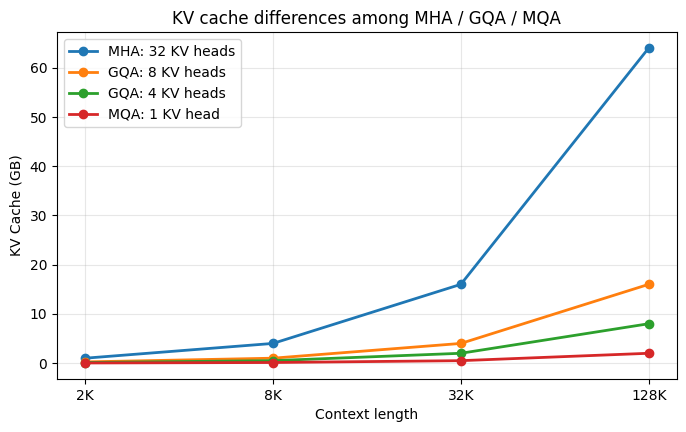

关键观察：上下文越长，减少 KV heads 带来的显存节省越明显。
注意：MQA/GQA 主要省 decode 阶段的 KV Cache 和显存带宽。


In [11]:
import matplotlib.pyplot as plt

num_layers = 32
num_query_heads = 32
head_dim = 128
seq_lengths = [2048, 8192, 32768, 131072]
seq_labels = ["2K", "8K", "32K", "128K"]
variants = {
    "MHA: 32 KV heads": 32,
    "GQA: 8 KV heads": 8,
    "GQA: 4 KV heads": 4,
    "MQA: 1 KV head": 1,
}

plt.figure(figsize=(8, 4.5))
for label, num_kv_heads in variants.items():
    sizes = [
        kv_cache_size(num_layers, num_kv_heads, head_dim, seq_len, 2) / 1024**3
        for seq_len in seq_lengths
    ]
    plt.plot(seq_labels, sizes, marker="o", linewidth=2, label=label)

plt.xlabel("Context length")
plt.ylabel("KV Cache (GB)")
plt.title("KV cache differences among MHA / GQA / MQA")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("关键观察：上下文越长，减少 KV heads 带来的显存节省越明显。")
print("注意：MQA/GQA 主要省 decode 阶段的 KV Cache 和显存带宽。")


**那为什么不全都用 MQA？**

因为省内存不是免费的。K/V head 太少，等于很多 Query head 被迫看同一套资料，模型表达能力可能下降。MQA 最省，但有时质量损失更明显；MHA 最稳，但 cache 最大；GQA 常常是工程折中。

| 方案 | K/V 怎么存 | 优点 | 缺点 |
|:---|:---|:---|:---|
| MHA | 每个 Q head 一组 K/V | 表达能力强，概念最直观 | KV Cache 最大 |
| MQA | 所有 Q head 共用一组 K/V | KV Cache 最小，decode 更省带宽 | 可能损失效果 |
| GQA | 几个 Q head 共用一组 K/V | 显存和效果之间折中 | 比 MQA 多占一点 cache |

一句话记住：**MHA 是“每个头一套 K/V”，MQA 是“所有头一套 K/V”，GQA 是“每组头一套 K/V”。**

## 5. 模型量化：用更少的位存储权重

训练时通常用 FP16（16 位浮点）存储权重，一个 7B 模型约 14 GB。量化把权重从 16 位降到 4 位或 8 位，显存占用直接减半甚至降到四分之一。先用具体的数字来理解量化是怎么做的。

In [12]:
import numpy as np

np.random.seed(42)
W = np.random.randn(4, 4).astype(np.float32)
print("原始权重 (FP32):")
print(np.round(W, 3))

scale = np.max(np.abs(W)) / 127
W_int8 = np.round(W / scale).clip(-127, 127).astype(np.int8)
print(f"\n缩放因子 scale = max(|W|) / 127 = {np.max(np.abs(W)):.4f} / 127 = {scale:.6f}")
print(f"\n量化后 (INT8):")
print(W_int8)

W_dequant = W_int8.astype(np.float32) * scale
error = np.mean(np.abs(W - W_dequant))
print(f"\n反量化还原:\n{np.round(W_dequant, 3)}")
print(f"\nMAE: {error:.5f}")
print(f"存储: 4 bytes/param → 1 byte/param，节省 75%")


原始权重 (FP32):
[[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]
 [ 0.242 -1.913 -1.725 -0.562]]

缩放因子 scale = max(|W|) / 127 = 1.9133 / 127 = 0.015065

量化后 (INT8):
[[  33   -9   43  101]
 [ -16  -16  105   51]
 [ -31   36  -31  -31]
 [  16 -127 -114  -37]]

反量化还原:
[[ 0.497 -0.136  0.648  1.522]
 [-0.241 -0.241  1.582  0.768]
 [-0.467  0.542 -0.467 -0.467]
 [ 0.241 -1.913 -1.717 -0.557]]

MAE: 0.00268
存储: 4 bytes/param → 1 byte/param，节省 75%


In [13]:
import numpy as np

np.random.seed(42)
W_large = np.random.randn(64, 64).astype(np.float32)

def quantize_uniform(W, n_bits):
    n_levels = 2 ** (n_bits - 1) - 1
    scale = np.max(np.abs(W)) / n_levels
    W_q = np.round(W / scale).clip(-n_levels, n_levels)
    return W_q * scale

print(f"{'位数':>4}  {'MAE':>8}  {'余弦相似度':>12}  {'存储占比':>8}")
print("-" * 38)
for bits in [16, 8, 6, 4, 3, 2]:
    W_r = W_large.copy() if bits == 16 else quantize_uniform(W_large, bits)
    mae = np.mean(np.abs(W_large - W_r))
    cos_sim = np.dot(W_large.flatten(), W_r.flatten()) / (np.linalg.norm(W_large) * np.linalg.norm(W_r) + 1e-8)
    ratio = bits / 16 * 100
    print(f"{bits:>4}  {mae:>8.5f}  {cos_sim:>12.8f}  {ratio:>7.0f}%")

print("\n4-bit 余弦相似度 > 0.99，方向基本不变。存储省了 75%。")


  位数       MAE         余弦相似度      存储占比
--------------------------------------
  16   0.00000    1.00000000      100%
   8   0.00774    0.99995960       50%
   6   0.03225    0.99930775       38%
   4   0.13990    0.98720088       25%
   3   0.32984    0.93346815       19%
   2   0.75890    0.52141723       12%

4-bit 余弦相似度 > 0.99，方向基本不变。存储省了 75%。


In [14]:
def model_size_gb(params_b, bits):
    return params_b * 1e9 * bits / 8 / 1e9

models_s = [("LLaMA-2 7B", 7), ("LLaMA-2 13B", 13), ("LLaMA-2 70B", 70), ("Qwen-2 72B", 72)]
formats = [("FP16", 16), ("INT8", 8), ("4-bit", 4), ("GGUF Q4_K_M", 4.5), ("GGUF Q2_K", 2.5)]

print(f"{'模型':<16} " + "".join(f"{fn:>16}" for fn, _ in formats))
print("-" * 96)
for mname, params in models_s:
    row = f"{mname:<16} "
    for fname, bits in formats:
        row += f"{model_size_gb(params, bits):>14.1f} GB"
    print(row)
print("\nGGUF Q4_K_M 约为 FP16 的 28%，质量损失可接受。")

模型                           FP16            INT8           4-bit     GGUF Q4_K_M       GGUF Q2_K
------------------------------------------------------------------------------------------------
LLaMA-2 7B                 14.0 GB           7.0 GB           3.5 GB           3.9 GB           2.2 GB
LLaMA-2 13B                26.0 GB          13.0 GB           6.5 GB           7.3 GB           4.1 GB
LLaMA-2 70B               140.0 GB          70.0 GB          35.0 GB          39.4 GB          21.9 GB
Qwen-2 72B                144.0 GB          72.0 GB          36.0 GB          40.5 GB          22.5 GB

GGUF Q4_K_M 约为 FP16 的 28%，质量损失可接受。


## 6. GGUF 格式详解

GGUF（GPT-Generated Unified Format）是 llama.cpp 生态使用的模型文件格式。它把模型权重、元数据、词表全部打包到一个文件里，不需要额外的配置文件。

GGUF 文件由三部分组成：

```
┌──────────────────────────┐
│ Header (文件头)            │
│   magic: "GGUF"           │
│   version: 3              │
│   tensor_count: N         │
│   metadata_kv_count: M    │
├──────────────────────────┤
│ Metadata (元数据区)        │
│   general.architecture    │
│   llama.context_length    │
│   tokenizer.ggml.tokens   │
│   ...                     │
├──────────────────────────┤
│ Tensor Data (权重数据区)   │
│   token_embd.weight       │
│   blk.0.attn_q.weight     │
│   blk.0.attn_k.weight     │
│   ... (重复 N 层)          │
│   output.weight           │
└──────────────────────────┘
```

GGUF 的量化类型命名规则（以 Q4_K_M 为例）：

- **Q4**：权重用 4 bit 存储
- **K**：k-quant 方法，不同层用不同精度
- **M**：Medium，在大小和精度之间折中

| 名称 | 比特数 | 7B 模型大小 | 适用场景 |
|:-----|:------|:----------|:---------|
| Q8_0 | 8 bit | ~7.2 GB | 精度最高 |
| Q5_K_M | ~5 bit | ~4.8 GB | 精度和速度平衡 |
| Q4_K_M | ~4.5 bit | ~4.1 GB | 性价比最高，最常用 |
| Q3_K_M | ~3.5 bit | ~3.3 GB | 内存紧张时使用 |
| Q2_K | ~2.5 bit | ~2.5 GB | 极端省内存，质量有损失 |

In [15]:
# 用 llama-cpp-python 加载 GGUF 模型
try:
    from llama_cpp import Llama
    print("llama-cpp-python 已安装")
    print("版本:", llama_cpp.__version__ if hasattr(llama_cpp, "__version__") else "未知")
except ImportError:
    print("llama-cpp-python 未安装。")
    print("安装方法:")
    print("  pip install llama-cpp-python")
    print("  macOS: CMAKE_ARGS='-DGGML_METAL=on' pip install llama-cpp-python")
    print("  CUDA:  CMAKE_ARGS='-DGGML_CUDA=on' pip install llama-cpp-python")

print()
print("使用方法:")
print("  from llama_cpp import Llama")
print('  llm = Llama(model_path="model-q4_k_m.gguf", n_ctx=512)')
print("  response = llm(prompt, max_tokens=50)")
print()
print("模型下载:")
print("  https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF")

llama-cpp-python 未安装。
安装方法:
  pip install llama-cpp-python
  macOS: CMAKE_ARGS='-DGGML_METAL=on' pip install llama-cpp-python
  CUDA:  CMAKE_ARGS='-DGGML_CUDA=on' pip install llama-cpp-python

使用方法:
  from llama_cpp import Llama
  llm = Llama(model_path="model-q4_k_m.gguf", n_ctx=512)
  response = llm(prompt, max_tokens=50)

模型下载:
  https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF


In [16]:
import os
import glob

import time

def find_gguf_model():
    search_paths = [
        os.path.expanduser("~/.cache/huggingface/hub"),
        os.path.expanduser("~/models"),
        os.path.expanduser("~/Downloads"),
    ]
    for path in search_paths:
        if os.path.exists(path):
            for f in glob.glob(os.path.join(path, "**/*.gguf"), recursive=True):
                return f
    return None

model_path = find_gguf_model()

if model_path:
    from llama_cpp import Llama
    file_size = os.path.getsize(model_path) / 1024**3
    print(f"加载: {os.path.basename(model_path)} ({file_size:.2f} GB)")

    llm = Llama(model_path=model_path, n_ctx=512, verbose=False)

    prompt = "The capital of France is"
    print(f"Prompt: {prompt}")

    start = time.perf_counter()
    response = llm(prompt, max_tokens=32, temperature=0.0)
    elapsed = time.perf_counter() - start

    text = response["choices"][0]["text"]
    n_tokens = response["usage"]["completion_tokens"]
    print(f"输出: {text}")
    print(f"速度: {n_tokens/elapsed:.1f} tokens/s")
else:
    print("未找到 GGUF 模型文件。")
    print("下载示例:")
    print("  wget https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF/resolve/main/qwen2.5-0.5b-instruct-q4_k_m.gguf")
    print("  然后用 Llama(model_path=...) 加载即可。")


未找到 GGUF 模型文件。
下载示例:
  wget https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct-GGUF/resolve/main/qwen2.5-0.5b-instruct-q4_k_m.gguf
  然后用 Llama(model_path=...) 加载即可。


## 7. PagedAttention (vLLM)

KV Cache 是连续分配的一大块内存。每个请求的生成长度不同，连续分配导致大量内存碎片。vLLM 的 PagedAttention 把 KV Cache 切成固定大小的「页」（block），像操作系统虚拟内存一样管理。

```
传统方式（连续内存）:
┌─────────────────────────┐
│ 请求A (500 tokens)       │
├─────────────────────────┤
│      (浪费的碎片)         │
├────────────┤
│ 请求B (100) │
└────────────┘

PagedAttention:
┌──┬──┬──┬──┬──┬──┬──┬──┐
│A1│B1│A2│C1│B2│A3│C2│A4│  每页固定大小
└──┴──┴──┴──┴──┴──┴──┴──┘  不连续但没碎片
```

In [17]:
import random

def simulate_memory(requests, block_size=16, alignment=64):
    contiguous_wasted = sum(((r + alignment - 1) // alignment) * alignment - r for r in requests)
    paged_wasted = sum((block_size - (r % block_size)) % block_size for r in requests)
    return contiguous_wasted, paged_wasted

random.seed(42)
scenarios = {
    "短文本 (10-100)": [random.randint(10, 100) for _ in range(100)],
    "混合 (10-500)":   [random.randint(10, 500) for _ in range(100)],
    "长文本 (100-2000)": [random.randint(100, 2000) for _ in range(50)],
}

for name, reqs in scenarios.items():
    cw, pw = simulate_memory(reqs)
    total = sum(reqs)
    print(f"{name:<20} 总{total:>6} tokens  连续浪费{cw/total*100:>5.1f}%  分页浪费{pw/total*100:>5.1f}%")

print("\n分页浪费率通常 3-5%，连续分配在 13-20%。")

短文本 (10-100)         总  5477 tokens  连续浪费 58.9%  分页浪费 13.3%
混合 (10-500)          总 26209 tokens  连续浪费 13.3%  分页浪费  2.9%
长文本 (100-2000)       总 53669 tokens  连续浪费  2.9%  分页浪费  0.7%

分页浪费率通常 3-5%，连续分配在 13-20%。


## 8. FlashAttention

KV Cache 解决了「少算」的问题，FlashAttention 解决了「算得快」的问题——更准确地说，是让 Attention 对 GPU 的内存层级更友好。

GPU 有两层存储，容量和速度差几个数量级：

```text
┌─────────────────────────────────────────────┐
│  HBM (显存)              容量大, 慢           │
│  例: A100 80GB, 带宽 ~2 TB/s                 │
│  存: 模型权重、KV Cache、激活值              │
│                                              │
│         ↑ 读 / 写 ↓  (来回搬数据)            │
│                                              │
│  SRAM (片上缓存)          容量小, 快 10x+    │
│  例: A100 192KB/block, 带宽 ~19 TB/s         │
│  存: 当前正在算的那一小块 Q/K/V              │
└─────────────────────────────────────────────┘
```

标准 Attention 的瓶颈不在乘加计算本身，而在 HBM 读写。朴素的实现会先把 $N \times N$ 的注意力分数矩阵整体写到 HBM，再读回来做 softmax，再写回去做加权求和。$N=8192$ 时这个中间矩阵要 16 GB，反复搬运的代价远超实际计算。

FlashAttention 的做法是 tiling：把 Q、K、V 切成能塞进 SRAM 的小块，每次只搬一小批进 SRAM，在里面算完这一块的全部 attention，只把最终输出写回 HBM。中间的注意力分数矩阵自始至终不落盘。

这里有一个技术难点：softmax 的分母 $\sum_j \exp(s_j)$ 依赖整行 K。如果 K 是分块处理的，怎么在没看完整行的情况下算正确的 softmax？答案是 online softmax——一边遍历 K 的分块，一边增量维护「当前已见最大值」和「当前累加分母」，最后修正出和完整 softmax 数学上完全相同的结果。直觉上可以理解为：不需要先把整行读完才能归一化，可以用一个滚动统计量把归一化「在线」地推进。

这里要强调一点：FlashAttention 是 **exact** 的，不是近似。它和标准 Attention 在数学上完全等价，只是把计算重排到对硬件友好的形式。这和后面会提到的 sparse attention、linear attention 不一样——后两者是为了把 $O(N^2)$ 真正降下来，付出的代价是牺牲精度或表达能力。FlashAttention 没动公式，只动了执行顺序。

代价是它对硬件的细节依赖很重，正确实现要处理 SRAM 大小、warp 调度、异步搬运等底层问题。本节只展开概念，完整的从零实现见附录 F。

### 版本演进：v1、v2、v3

FlashAttention 自 2022 年提出后经历了三次主要迭代，每一版针对上一版的瓶颈做了不同优化：

| 版本 | 年份 | 关键改进 | 加速来源 |
|:---|:---|:---|:---|
| v1 | 2022 (Dao) | 提出 tiling + online softmax，HBM 读写从 $O(N^2)$ 降到 $O(N^2/M)$ | 减少显存读写 |
| v2 | 2023 (Dao) | 重排循环结构（外层遍历 Q，内层遍历 K/V），non-matmul 计算减少 2-4× | matmul 占比提升 |
| v3 | 2024 (NVIDIA) | 异步 warp-specialization + TMA + FP8，针对 Hopper 架构 | 比 v2 再快 1.5-2× |

v1 解决的是「中间注意力矩阵写回 HBM」这个最大的带宽浪费。把 Q、K、V 切成块在 SRAM 里完成计算，结果只写一次。

v2 注意到一个细节：v1 的循环外层是 K/V、内层是 Q，导致每次外层迭代都要更新所有 Q 块的累积结果，non-matmul 操作多。v2 把循环顺序反过来——外层 Q、内层 K/V——每个 Q 块算完就输出，non-matmul 工作量降了 2-4 倍，matmul 在总 FLOPs 里的占比从 25-50% 提升到 70-85%。GPU 上 matmul 单元远比通用 ALU 快，所以这一步实际加速明显。

v3 是 NVIDIA 团队针对 Hopper 架构（H100/H200）做的专属优化。它用到了 Hopper 才有的硬件特性：TMA（Tensor Memory Accelerator，异步搬运张量）和 FP8 Tensor Core。warp-specialization 让 producer warp 异步加载下一批数据、consumer warp 同时计算，掩盖了 HBM 延迟。代价是只在新硬件上有效——A100 上跑不到这些增益。

In [18]:
def standard_attn_memory(batch, heads, seq, bytes=2):
    return batch * heads * seq * seq * bytes

def flash_attn_memory(batch, heads, seq, d_head, bytes=2):
    return batch * seq * heads * d_head * bytes

def fmt(b):
    return f"{b/1024**3:.1f} GB" if b >= 1024**3 else f"{b/1024**2:.0f} MB"

print(f"{'序列长度':>8}  {'标准Attention':>15}  {'FlashAttention':>15}  {'节省':>8}")
print("-" * 55)
for seq in [512, 1024, 2048, 4096, 8192, 16384]:
    std = standard_attn_memory(1, 32, seq)
    flash = flash_attn_memory(1, 32, seq, 128)
    saving = (1 - flash / std) * 100
    print(f"{seq:>8d}  {fmt(std):>15}  {fmt(flash):>15}  {saving:>7.1f}%")

print("\n8192 token 时，标准要 16 GB 存中间矩阵，Flash 只要 4 MB。")

    序列长度      标准Attention   FlashAttention        节省
-------------------------------------------------------
     512            16 MB             4 MB     75.0%
    1024            64 MB             8 MB     87.5%
    2048           256 MB            16 MB     93.8%
    4096           1.0 GB            32 MB     96.9%
    8192           4.0 GB            64 MB     98.4%
   16384          16.0 GB           128 MB     99.2%

8192 token 时，标准要 16 GB 存中间矩阵，Flash 只要 4 MB。


In [19]:
import torch
import torch.nn.functional as F
import math
import time

has_flash = hasattr(torch.nn.functional, "scaled_dot_product_attention")
print(f"支持 SDPA: {has_flash}")

if has_flash:
    batch, heads, seq, dim = 2, 8, 512, 64
    q = torch.randn(batch, heads, seq, dim)
    k = torch.randn(batch, heads, seq, dim)
    v = torch.randn(batch, heads, seq, dim)

    start = time.perf_counter()
    for _ in range(100):
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(dim)
        out_std = F.softmax(scores, dim=-1) @ v
    t_std = time.perf_counter() - start

    start = time.perf_counter()
    for _ in range(100):
        out_flash = F.scaled_dot_product_attention(q, k, v)
    t_flash = time.perf_counter() - start

    diff = (out_std - out_flash).abs().max().item()
    print(f"标准: {t_std*1000:.1f} ms, SDPA: {t_flash*1000:.1f} ms, 加速: {t_std/t_flash:.1f}x")
    print(f"最大差异: {diff:.2e}")


支持 SDPA: True


标准: 4718.6 ms, SDPA: 1196.8 ms, 加速: 3.9x
最大差异: 3.87e-07


**FlashAttention 在 MoE 推理下的位置**

MoE（Mixture-of-Experts）模型把 FFN 拆成多个 expert，按 token 动态路由。这里要分清：MoE 改的是 FFN 层，attention 层仍然是 dense 的——所有 token 走同一套 Q/K/V 权重。也就是说，FlashAttention 在 MoE 模型里依然全程适用，prefill 和 decode 两个阶段都受益。

需要注意的是 expert routing 之后产生的副作用：不同 token 被路由到不同 expert，每个 expert 收到的 token 数量不均。为了在 GPU 上并行计算，通常要把同一个 expert 的 token gather 到一起，再 batch 起来做 FFN。如果某个 expert 只分到 3 个 token，而另一个分到 50 个，按最大长度 padding 就会浪费计算。这部分浪费发生在 FFN，不在 attention——attention 的 batch 始终是完整的 token 序列，没有 padding 问题。

所以 MoE 推理里 attention 的开销和 dense 模型基本一致，真正的工程难点在 expert 路由后的负载不均和通信开销。FlashAttention 在这里扮演的角色没有变化：让每层 attention 跑得更快、更省显存，给 expert 部分腾出更多预算。

完整的 FlashAttention 从零实现（包含 tiling、online softmax 的逐步推导和手算）见附录 F。

### 推理两阶段：prefill 与 decode 形态不同

前面讲的 FlashAttention 都是训练和 prefill 的视角：Q 是一整段序列，形状 $[S_q, d]$。到了 decode 阶段，每生成一个新 token，Q 只有一行，形状退化成 $[1, d]$。这一个差别，决定了 FlashAttention 在两个阶段要采用不同的并行方式。

prefill 没有特别的问题。一次性处理整段 prompt 时，Q 有 $S_q$ 行，外层循环遍历 Q 块、把不同块分到不同 SM 上并行的那套机制照常工作。prefill 是计算瓶颈（compute-bound），FlashAttention 的标准 tiling 直接适用。

decode 则完全不同。每步只有一个新 token，Q 只有一行，标准 FlashAttention「外层循环遍历 Q 块」的并行方式直接失效——整个序列维度退化成单块，只有一个 SM 在算，其余 SM 闲置。更关键的是 decode 受显存带宽限制（memory-bound）：计算量很少（Q 只有一行，$QK^\top$ 形状是 $[1, S]$），却要把全部历史 token 的 K、V 从 HBM 读一遍。`算术强度`（每读一字节能做多少次浮点运算）极低，GPU 的算力大量空闲，时间都耗在搬运数据上。

`FlashDecoding` 针对的就是 decode 的并行失效。做法是把沿 Q 维度的并行改成沿 K/V 维度的并行：把整段 KV cache 切成若干段分给多个 SM，每段独立算出一组局部统计量——局部最大值 $m$、局部分母 $d$、局部加权和 $o$，最后用 online softmax 的可结合性把各段合并成全局结果。

这里用的就是附录 F 推导过的 online softmax，区别只在于分块的目的：附录 F 是单个 SM 内沿 K 串行累加，省的是 HBM 读写；FlashDecoding 是多个 SM 沿 K 并行分段，要的是把闲置的算力用起来。两者用的是同一条合并公式，合并结果和一次性算完全相同（只有浮点误差层面的差异）。

下面两段代码分别把这两件事量化：decode 为什么是带宽瓶颈，以及 split-K 的分段合并为什么和标准 attention 数学等价。

在主流推理架构里，还有两个细节会和 FlashDecoding 叠加。第一是 GQA/MQA：多个 Q head 共享同一组 K/V head，decode 时同一块 KV 被多个 Q head 复用，读取量进一步摊薄。第二是分页 KV cache：PagedAttention 把 KV cache 切成物理上不连续的页，FlashAttention kernel 要通过 `block table` 间接寻址去取每一块 K/V。这两点合在一起，就是 vLLM、SGLang 等推理引擎里 attention 的真实形态。

In [1]:
# decode 一步：算得少，读得多 —— 为什么 decode 受显存带宽限制

def decode_kv_bytes(seq, n_kv_heads, head_dim, bytes_per_elem=2):
    # 每生成一个 token，要把全部历史 K、V 从 HBM 读一遍（K 和 V 各一份）
    return 2 * seq * n_kv_heads * head_dim * bytes_per_elem

def decode_flops(seq, n_q_heads, head_dim):
    # Q 只有一行：Q @ K^T 是 [1, seq]，softmax 后再 @ V 得 [1, d]，两步 matmul
    qk = 2 * seq * n_q_heads * head_dim
    pv = 2 * seq * n_q_heads * head_dim
    return qk + pv

# Llama 级别配置：32 个 Q head、8 个 KV head（GQA）、head_dim=128、上下文 4096
seq, n_q, n_kv, d = 4096, 32, 8, 128

kv_bytes = decode_kv_bytes(seq, n_kv, d)
flops = decode_flops(seq, n_q, d)

print(f"decode 一步读取 KV cache: {kv_bytes/1024/1024:>6.1f} MB")
print(f"decode 一步浮点计算量:   {flops/1e6:>6.1f} MFLOPs")
print(f"算术强度: {flops/kv_bytes:.1f} FLOP/byte")
print()
print("A100 的算力/带宽平衡点约 100 FLOP/byte。decode 的算术强度远低于这个值，")
print("说明 GPU 大部分时间在等数据从显存搬进来，而不是在算。")

decode 一步读取 KV cache:   16.0 MB
decode 一步浮点计算量:     67.1 MFLOPs
算术强度: 4.0 FLOP/byte

A100 的算力/带宽平衡点约 100 FLOP/byte。decode 的算术强度远低于这个值，
说明 GPU 大部分时间在等数据从显存搬进来，而不是在算。


In [1]:
import torch
import math

torch.manual_seed(0)

# 小规模、手算友好：head_dim=4，KV cache 长 8，Q 只有 1 行（模拟 decode 一步）
d = 4
seq = 8
q = torch.randn(1, d)            # [1, d]：当前要生成的这一个 token 的 Q
K = torch.randn(seq, d)          # [seq, d]：全部历史 token 的 K
V = torch.randn(seq, d)          # [seq, d]：全部历史 token 的 V
scale = 1.0 / math.sqrt(d)

def attn_ref(q, K, V):
    # 参照：标准 softmax attention
    s = (q @ K.transpose(-2, -1)) * scale   # [1, seq]
    p = torch.softmax(s, dim=-1)            # [1, seq]
    return p @ V                            # [1, d]

def flash_decode_splitk(q, K, V, n_split=2):
    # 沿 K/V 的序列维度切成 n_split 段，各算局部 (m, d, o)，再合并
    n = K.shape[0]
    bounds = [(i * n // n_split, (i + 1) * n // n_split) for i in range(n_split)]
    ms, ds, outs = [], [], []
    for a, b in bounds:
        Kj, Vj = K[a:b], V[a:b]
        s = (q @ Kj.transpose(-2, -1)) * scale   # [1, len]
        m = s.max()                              # 这一段的局部最大值
        p = torch.exp(s - m)                     # 减局部 max，数值稳定
        ms.append(m)
        ds.append(p.sum())                       # 局部分母（未归一化）
        outs.append(p @ Vj)                      # 局部加权和（未归一化）
    # 合并各段：online softmax 的可结合性
    m_all = torch.stack(ms).max()                # 全局最大值
    d_all = sum(di * torch.exp(mi - m_all) for di, mi in zip(ds, ms))
    o_all = sum(oi * torch.exp(mi - m_all) for oi, mi in zip(outs, ms))
    return o_all / d_all                         # 归一化得到最终输出

o_ref = attn_ref(q, K, V)
o_split = flash_decode_splitk(q, K, V, n_split=2)

print("标准 attention 输出: ", [round(x, 4) for x in o_ref[0].tolist()])
print("split-K 合并后输出:  ", [round(x, 4) for x in o_split[0].tolist()])
print("最大绝对差:          ", (o_ref - o_split).abs().max().item())
print()
print("两段各自独立算 partial softmax，合并后和一次性算完全相同（仅浮点误差）。")

标准 attention 输出:  [-0.4345, -0.1006, 0.3723, 0.537]
split-K 合并后输出:   [-0.4345, -0.1006, 0.3723, 0.537]
最大绝对差:           5.960464477539063e-08

两段各自独立算 partial softmax，合并后和一次性算完全相同（仅浮点误差）。


## 9. 推理的两阶段：Prefill vs Decode

| | Prefill | Decode |
|------|-----------|-------|
| 做什么 | 一次性处理 prompt | 逐个生成 token |
| 瓶颈 | 计算 | 显存带宽 |
| 优化 | FlashAttention | KV Cache + PagedAttention + FlashDecoding |

Prefill (50 tokens): 65.33 ms


Decode 平均: 56.80 ms/token


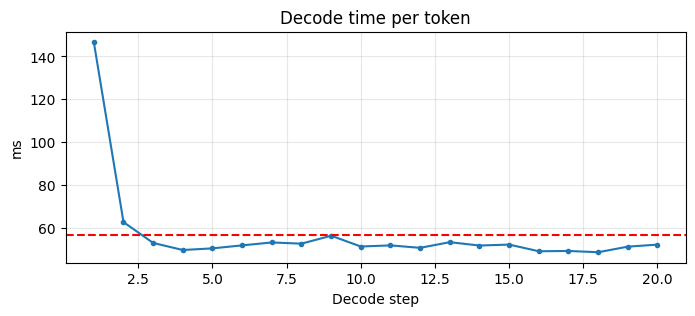

Prefill 一次性（并行），Decode 串行（逐 token）。


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

attn_demo = AttentionWithKVCache(d_model=256, num_heads=8)
prompt_len = 50
prompt = torch.randn(1, prompt_len, 256)

attn_demo.reset_cache()
start = time.perf_counter()
_ = attn_demo(prompt, use_cache=True)
t_prefill = time.perf_counter() - start
print(f"Prefill ({prompt_len} tokens): {t_prefill*1000:.2f} ms")

decode_times = []
for _ in range(20):
    new_tok = torch.randn(1, 1, 256)
    start = time.perf_counter()
    _ = attn_demo(new_tok, use_cache=True)
    decode_times.append((time.perf_counter() - start) * 1000)

avg_d = np.mean(decode_times)
print(f"Decode 平均: {avg_d:.2f} ms/token")

plt.figure(figsize=(8, 3))
plt.plot(range(1, 21), decode_times, marker=".")
plt.axhline(avg_d, color="red", linestyle="--")
plt.xlabel("Decode step")
plt.ylabel("ms")
plt.title("Decode time per token")
plt.grid(True, alpha=0.3)
plt.show()
print("Prefill 一次性（并行），Decode 串行（逐 token）。")


## 10. Continuous Batching

传统 batching 等整个 batch 完成才处理下一个。Continuous Batching 让完成的请求立即释放，新请求立即填入。

```
传统: 请求A [========] 请求B [===]  空等...  请求C [等待...]
Continuous: 请求A [========] 请求B [===] 请求C [====...]
                              ↑ B 结束后 C 立即开始
```

vLLM、TensorRT-LLM、TGI 都使用了 Continuous Batching。

In [21]:
import random

def simulate_batching(num_requests=20, max_batch=4):
    random.seed(42)
    lengths = [max(5, int(random.gauss(50, 20))) for _ in range(num_requests)]
    t_trad = sum(max(lengths[i:i+max_batch]) for i in range(0, num_requests, max_batch))

    active = lengths[:max_batch]
    remaining = lengths[max_batch:]
    t_cont = 0
    while active:
        t_cont += 1
        new_active = []
        for l in active:
            if l > 1:
                new_active.append(l - 1)
            elif remaining:
                new_active.append(remaining.pop(0))
        active = new_active
    return t_trad, t_cont

print(f"{'max_batch':>10} {'传统':>8} {'Continuous':>12} {'提升':>6}")
print("-" * 40)
for mb in [2, 4, 8, 16]:
    t1, t2 = simulate_batching(max_batch=mb)
    print(f"{mb:>10} {t1:>8} {t2:>12} {t1/t2:>5.1f}x")


 max_batch       传统   Continuous     提升
----------------------------------------
         2      563          516   1.1x
         4      332          268   1.2x
         8      213          167   1.3x
        16      149          105   1.4x


## 11. 加速手段总结

| 技术 | 做什么 | 加速/节省 | 精度损失 |
|------|--------|---------|---------|
| KV Cache | 缓存已算的 K、V | 计算 10-50x | 无 |
| KV Cache 量化 | INT8/INT4 存 K、V | 内存 2-4x | 轻微 |
| MQA/GQA | 减少 K/V head 数 | KV Cache 4-32x | 轻微到中等 |
| FlashAttention | SRAM 里算 attention | 速度 2-4x，内存 10-20x | 无 |
| 模型量化 | 更少 bit 存权重 | 内存 2-4x | 轻微 |
| PagedAttention | 分页管理 KV Cache | 利用率 100% | 无 |
| Continuous Batching | 动态调度 | 吞吐 5-10x | 无 |
| GGUF | 统一打包格式 | CPU/边缘部署 | 取决于量化 |

投机解码在下一个 notebook 专门讲。

## 小结

- 朴素自回归生成会反复处理历史前缀，重复处理量随生成长度呈 O(N²) 级增长
- KV Cache 存已算的 K、V，避免重算历史 token 的 K/V 和隐藏状态
- KV Cache 仍会占内存并在 decode 阶段被读取，长序列 + 大模型时显存和带宽压力很大
- MQA/GQA 减少 K/V head 数，直接缩小 KV Cache
- 模型量化把 FP16 压到 INT8/INT4，体积减半到四分之一
- GGUF 是 llama.cpp 的标准格式，llama-cpp-python 可直接加载
- FlashAttention 在 SRAM 里算，中间结果不写回显存，数学等价
- PagedAttention 分页管理 KV Cache，消除碎片
- prefill（计算瓶颈）vs decode（常见为带宽瓶颈）
- decode 阶段 Q 只有一行，FlashAttention 沿 K/V 维度切分并行（FlashDecoding），各段用 online softmax 合并
- Continuous Batching 吞吐提升 5-10x

下一节：投机解码——用小模型猜、大模型验证。

## 作业

> 可以让 AI 解释概念，但请亲手跑代码、填答案。

**作业 1：KV Cache 内存计算**

一个模型有 32 层、32 头、每头 128 维。FP16 存储，生成 4096 token。单个请求的 KV Cache 占多少 MB？

小提示：`2 × layers × heads × head_dim × seq_len × 2`

In [22]:
num_layers = 32
num_heads = 32
head_dim = 128
seq_len = 4096

kv_bytes = 2 * num_layers * num_heads * head_dim * seq_len * 2
kv_mb = kv_bytes / (1024 * 1024)
print(f"KV Cache: {kv_mb:.0f} MB")
assert abs(kv_mb - 2048) < 10
print("✅ 作业 1 通过")

KV Cache: 2048 MB
✅ 作业 1 通过


**作业 2：量化模型大小**

13B 参数模型，从 FP16 量化到 4-bit，缩小到多少 GB？

小提示：FP16 每参数 2 字节，4-bit 每参数 0.5 字节。

In [23]:
params = 13e9
size_fp16 = params * 2 / 1e9
size_4bit = params * 0.5 / 1e9
print(f"FP16: {size_fp16:.1f} GB → 4-bit: {size_4bit:.1f} GB")
assert abs(size_4bit - 6.5) < 0.5
print("✅ 作业 2 通过")

FP16: 26.0 GB → 4-bit: 6.5 GB
✅ 作业 2 通过


**作业 3：FlashAttention 内存节省**

batch=1, heads=32, seq=8192, FP16。注意力矩阵占多少 GB？

小提示：元素数 × 2 bytes → GB。

In [24]:
batch, heads, seq = 1, 32, 8192
attn_bytes = batch * heads * seq * seq * 2
attn_gb = attn_bytes / 1024**3
print(f"注意力矩阵: {attn_gb:.1f} GB")
assert abs(attn_gb - 4.0) < 0.1
print("✅ 作业 3 通过")

注意力矩阵: 4.0 GB
✅ 作业 3 通过


## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017
- Shazeer, [Fast Transformer Decoding: One Write-Head is All You Need](https://arxiv.org/abs/1911.02150), 2019
- Ainslie et al., [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245), 2023
- Dao et al., [FlashAttention](https://arxiv.org/abs/2205.14135), 2022
- Dao, [FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning](https://arxiv.org/abs/2307.08691), 2023
- Shah et al., [FlashAttention-3: Fast and Accurate Attention with Asynchrony and Low-precision](https://arxiv.org/abs/2407.08608), 2024
- Kwon et al., [PagedAttention (vLLM)](https://arxiv.org/abs/2309.06180), 2023
- Frantar et al., [GPTQ](https://arxiv.org/abs/2210.17323), 2022
- Lin et al., [AWQ](https://arxiv.org/abs/2306.00978), 2023
- [GGUF Specification](https://github.com/ggerganov/ggml/blob/master/docs/gguf.md)
- [llama.cpp](https://github.com/ggerganov/llama.cpp)
- [vLLM](https://github.com/vllm-project/vllm)
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)